# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [ ]:
# Patch para GPU de Ariel (AMD RX 6750 XT)
%env HSA_OVERRIDE_GFX_VERSION=10.3.0
%env MIOPEN_DEBUG_FIND_ENFORCE=2

env: HSA_OVERRIDE_GFX_VERSION=10.3.0
env: MIOPEN_DEBUG_FIND_ENFORCE=2


In [1]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.13.2


## Dataset

In [2]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [3]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

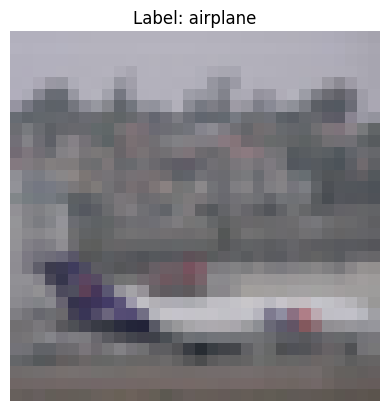

In [4]:
ds_train = ds['train']
ds_test = ds['test']

plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

extraemos todo el dataset a memoria y normalizamos las imágenes al rango [0, 1]

In [5]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

## Ejercicio 1. Visión por Computadora

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    # Asumiendo estas son Relu como en el tutorial de Tensorflow
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
    layers.Dense(10, activation='softmax', name='output')
])

In [ ]:
model.summary()

Model: "sequential_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train

array([0, 6, 0, ..., 1, 1, 5], shape=(50000,))

Observamos que a cada elemento del conjunto de entrenamiento le corresponde en el arreglo `y_train` un número que identifica su clase.
Por lo tanto, se requiere que la función de loss utilizada acepte las clases del dataset de esta forma.
La función `keras.losses.SparseCategoricalCrossentropy()` utilizada en el tutorial de Tensorflow indica en su documentación que espera clases justamente de esta forma, como enteros.

In [ ]:
model.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

Normalizamos las imágenes del conjunto de test también al rango $[0,1]$:

In [6]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [ ]:
y_test

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

A diferencia del tutorial, separamos parte de los datos para validación, en vez de usar el conjunto de test como tal. Esto nos permitirá tener mejores medidas del error de la red entrenada (TODO: Ok? Mejor explicación?):

In [7]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

Clonamos el modelo para poder entrenarlo con nuevos parámetros de entrenamiento más adelante:

In [ ]:
model_10ep = keras.models.clone_model(model)
history_10ep = model_10ep.fit(
    x_train_split, y_train_split, epochs=10,
    validation_data=(x_val_split, y_val_split)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4087 - loss: 1.5857 - val_accuracy: 0.5212 - val_loss: 1.3012
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5934 - loss: 1.1278 - val_accuracy: 0.6470 - val_loss: 1.0092
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6730 - loss: 0.9232 - val_accuracy: 0.6536 - val_loss: 0.9987
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7214 - loss: 0.7921 - val_accuracy: 0.6816 - val_loss: 0.9133
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7554 - loss: 0.7021 - val_accuracy: 0.7228 - val_loss: 0.8135
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7836 - loss: 0.6136 - val_accuracy: 0.7198 - val_loss: 0.8400
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8104 - loss: 0.5416 - val_accuracy: 0.7290 - val_loss: 0.8488
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8329 - loss: 0.4747 - 

In [10]:
def plot_history_graphics(history):
    fig = plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Error de entrenamiento')
    plt.plot(history.history['val_loss'], label='Error de validación')
    plt.title('Curvas de error (categorical cross-entropy)')
    plt.xlabel('Épocas')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy del entrenamiento') # TODO: Cambiar por porcentaje de error con 1-acc?
    plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
    plt.title('Curvas de accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

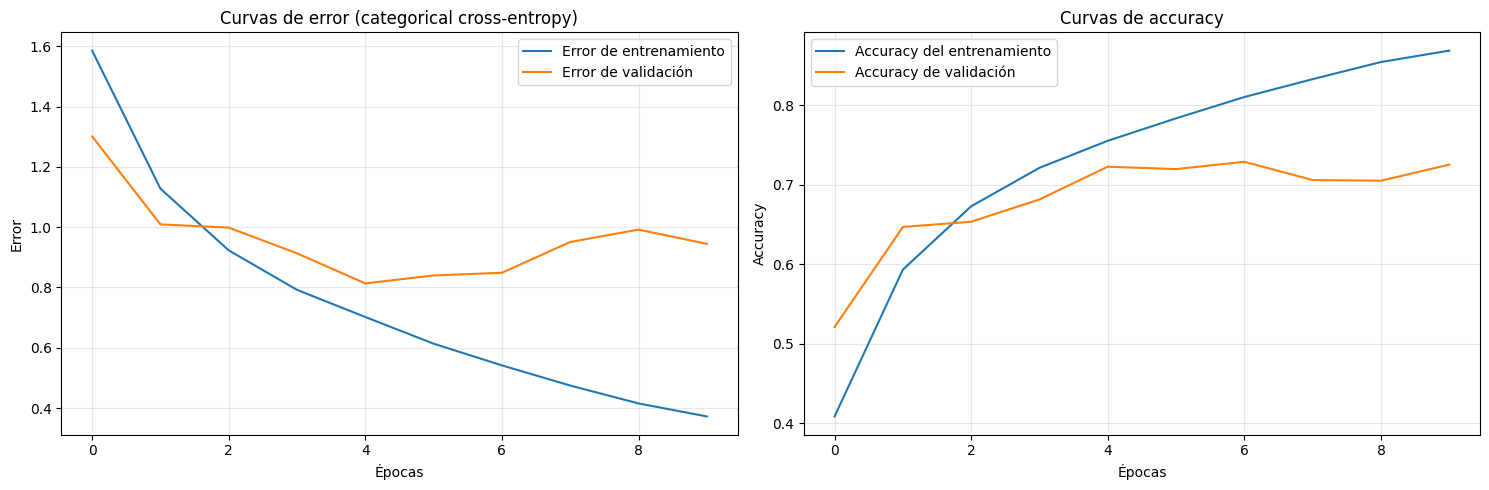

In [ ]:
plot_history_graphics(history_10ep)

In [ ]:
model_10ep.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7248 - loss: 0.9230


[0.9230079054832458, 0.7247999906539917]

TODO: Observaciones // redacción // formato Latex para números // revisar valores, etc-> El error de entrenamiento baja, y el accuracy de entrenamiento sube. Lo mismo sucede al principio con el conjunto de validación, pero luego se estanca su crecimiento del accuracy, e incluso su error sube algo más en las últimas épocas. La accuracy sobre el conjunto de test es de 73%, y el error de 0.96, probablemente se pueden mejorar (disminuir el error, y aumentar el accuracy).

A pesar de esto, parece que el accuracy se encuentra en aumento con una pendiente considerable, y lo mismo para el descenso del error de entrenamiento.
Es posible entonces que el error de entrenamiento mejore con mayor cantidad de épocas. Elegimos arbitrariamente el doble, 20 épocas.

Utilizamos una copia del modelo antes del entrenamiento anterior para evitar entrenar el antes ya entrenado (y obtener curvas de error desde el principio):

In [ ]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

In [ ]:
model_20ep = keras.models.clone_model(model)
history_20ep = model_20ep.fit(
    x_train_split, y_train_split, epochs=20,
    validation_data=(x_val_split, y_val_split)
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3987 - loss: 1.6146 - val_accuracy: 0.5032 - val_loss: 1.3280
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5787 - loss: 1.1763 - val_accuracy: 0.6158 - val_loss: 1.0948
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6520 - loss: 0.9796 - val_accuracy: 0.6302 - val_loss: 1.0516
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7054 - loss: 0.8374 - val_accuracy: 0.6674 - val_loss: 0.9500
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7418 - loss: 0.7340 - val_accuracy: 0.6996 - val_loss: 0.8725
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7755 - loss: 0.6447 - val_accuracy: 0.6930 - val_loss: 0.9022
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8050 - loss: 0.5682 - val_accuracy: 0.7258 - val_loss: 0.8810
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8259 - loss: 0.5005 - 

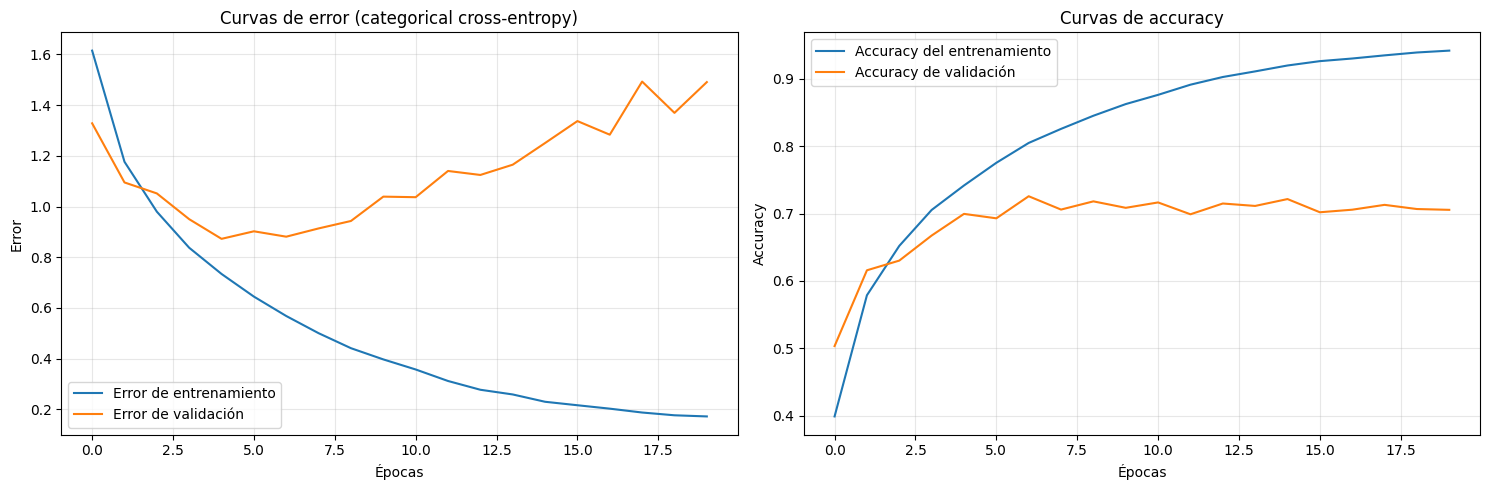

In [ ]:
plot_history_graphics(history_20ep)

In [ ]:
test_loss, test_acc = model_20ep.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.6992 - loss: 1.5072


Es claro con una mayor cantidad de épocas que el estancamiento del accuracy del conjunto de validación observado con 10 épocas es producto de overfitting, lo cual se evidencia especialmente con 20 épocas. Si bien a mayor cantidad de épocas se logra un menor error en el conjunto de test, el accuracy del conjunto de validación se mantiene en torno al 70%, y su error de categorical cross-entropy de hecho aumenta partiendo de alrededor de la 10° época. TODO: Redacción / números

Además, ambas métricas retornan peores resultados para el conjunto de test respecto a las vistas con 10 épocas: un accuracy de 68% (5% menos) y un loss mayor de 1.42.

Dicho esto, plantearemos una modificación a la arquitectura de la CNN que permita obtener una mejora en el error obtenido:

#### TODO: ENCONTRAR UN CAMBIO QUE AYUDE A MEJORAR LA PERFORMANCE DE LA RED!!!

In [ ]:
model_enhanced = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
    layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
    layers.Flatten(name='flatten'),
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dense(10, activation='softmax', name='output')
])

In [ ]:
model_enhanced = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
    layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
    layers.Flatten(name='flatten'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(10, activation='softmax', name='output')
])

In [ ]:
model_enhanced.summary()

Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_enhanced.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [8]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

In [ ]:
history_enhanced = model_enhanced.fit(
    x_train_split, y_train_split, epochs=10,
    validation_data=(x_val_split, y_val_split)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4103 - loss: 1.5935 - val_accuracy: 0.5414 - val_loss: 1.2896
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6044 - loss: 1.1070 - val_accuracy: 0.6414 - val_loss: 0.9997
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6839 - loss: 0.8941 - val_accuracy: 0.6872 - val_loss: 0.8754
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7345 - loss: 0.7608 - val_accuracy: 0.7124 - val_loss: 0.8461
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7632 - loss: 0.6748 - val_accuracy: 0.7324 - val_loss: 0.7643
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7911 - loss: 0.5961 - val_accuracy: 0.7270 - val_loss: 0.8315
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8116 - loss: 0.5335 - val_accuracy: 0.7466 - val_loss: 0.7559
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8315 - loss: 0

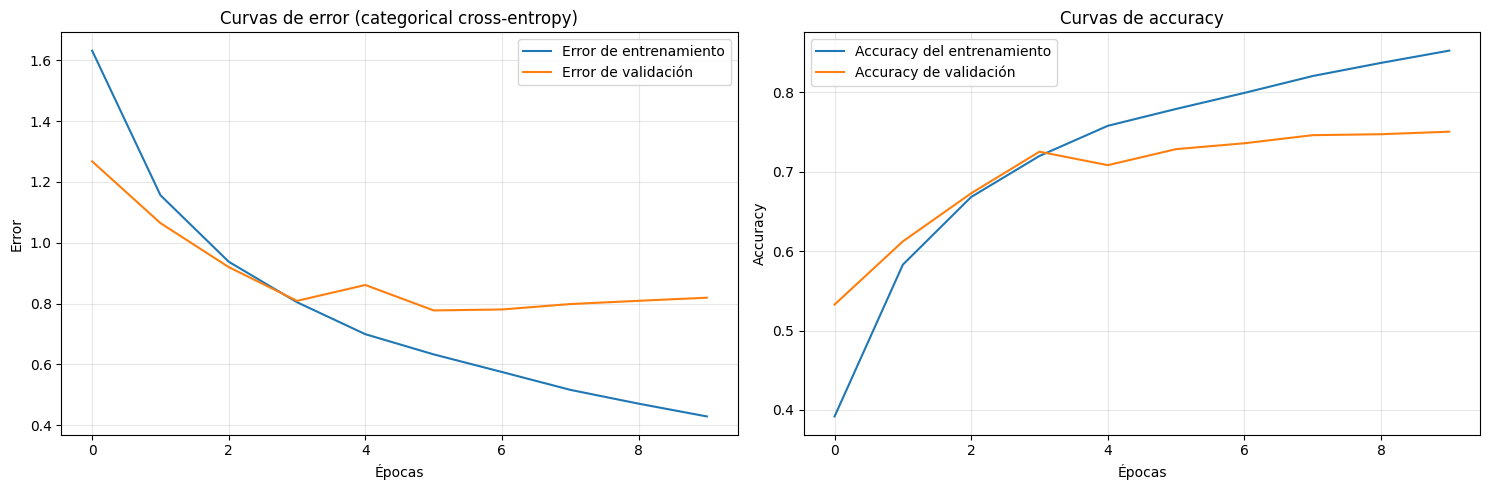

In [ ]:
plot_history_graphics(history_enhanced)

In [ ]:
model_enhanced.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7409 - loss: 0.8512


[0.851231038570404, 0.7408999800682068]

## Ejercicio 2. Dropout

In [9]:
def create_model_droput(prob, two_drops): # two_drops es para hacer uno o dos dropouts, capaz se puede hacer mas lindo
    if (not two_drops):
        model_drop = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(prob, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])
    else:
        model_drop = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(prob, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dropout(prob, name='dropout_2'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])

    return model_drop

Entrenamos 5 modelos, 4 en los cuales variamos la cantidad de capas de dropout valores de p pedidos en el enunciado y un modelo extra con 2 capas de dropout y p = 0.7 para experimentar con un valor de p mas alto.
Utilizamos 40 epocas de entrenamiento, el doble de las utilizadas en el ejericio previo.

Entrenamos el modelo model_drop_11 con p = 0.2 y una capa droput

In [13]:
model_drop_11 = create_model_droput(0.2, False)
model_drop_11.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model_drop_11.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_11 = model_drop_11.fit(
    x_train_split, y_train_split, epochs=20,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.3902 - loss: 1.6342 - val_accuracy: 0.5456 - val_loss: 1.2565
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5944 - loss: 1.1268 - val_accuracy: 0.6356 - val_loss: 1.0113
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6738 - loss: 0.9230 - val_accuracy: 0.6926 - val_loss: 0.8713
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7190 - loss: 0.7945 - val_accuracy: 0.7112 - val_loss: 0.8197
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7503 - loss: 0.7090 - val_accuracy: 0.7324 - val_loss: 0.7764
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7743 - loss: 0.6421 - val_accuracy: 0.7240 - val_loss: 0.7701
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7933 - loss: 0.5877 - val_accuracy: 0.7466 - val_loss: 0.7232
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8090 - loss: 0.5420 

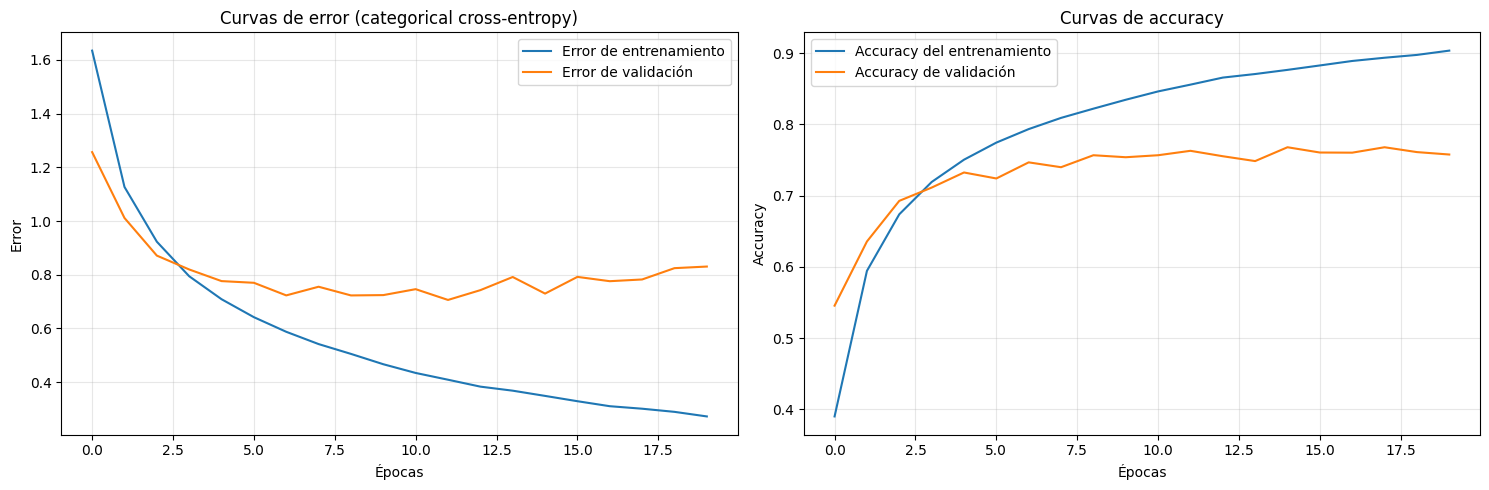

In [15]:
plot_history_graphics(history_drop_11)

In [31]:
model_drop_11.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 5ms/step - accuracy: 0.7599 - loss: 0.8440


[0.8439875841140747, 0.7598999738693237]

Podemos ver que, en principio, agregar una capa de dropout (luego de la ultima capa convolucional) obtenemos un resultado similar en el ejericio 1 (esto sin haber hallado aun la modificación que mejore en almenos 3%) en el cual la curva de error de entrenamiento baja y la de validacion sube. El overfitting observado previamente se mantiene lo cual nos dice que el valor p = 0.2, osea, un 20% de probabilidad de ignorar una neurona de las que conectan la ultima capa convolucional con la capa flatten, no es apropiado para evitar el sobreajuste.

Las curvas de accuracy tento de entrenamiento como de validación, son similares a las del ejericio 1, con un pequeño aumento del accuracy de validación a 75%.

Entrenamos el modelo model_drop_12 con p = 0.2 y dos capas droput

In [16]:
model_drop_12 = create_model_droput(0.2, True)
model_drop_12.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_drop_12.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_12 = model_drop_12.fit(
    x_train_split, y_train_split, epochs=20,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.3489 - loss: 1.7385 - val_accuracy: 0.5010 - val_loss: 1.3548
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5505 - loss: 1.2489 - val_accuracy: 0.6050 - val_loss: 1.1181
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6346 - loss: 1.0367 - val_accuracy: 0.6672 - val_loss: 0.9299
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6830 - loss: 0.9068 - val_accuracy: 0.6790 - val_loss: 0.8775
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7146 - loss: 0.8221 - val_accuracy: 0.7084 - val_loss: 0.8412
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7389 - loss: 0.7504 - val_accuracy: 0.7112 - val_loss: 0.8113
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7566 - loss: 0.6989 - val_accuracy: 0.7354 - val_loss: 0.7460
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7726 - loss: 0.6532

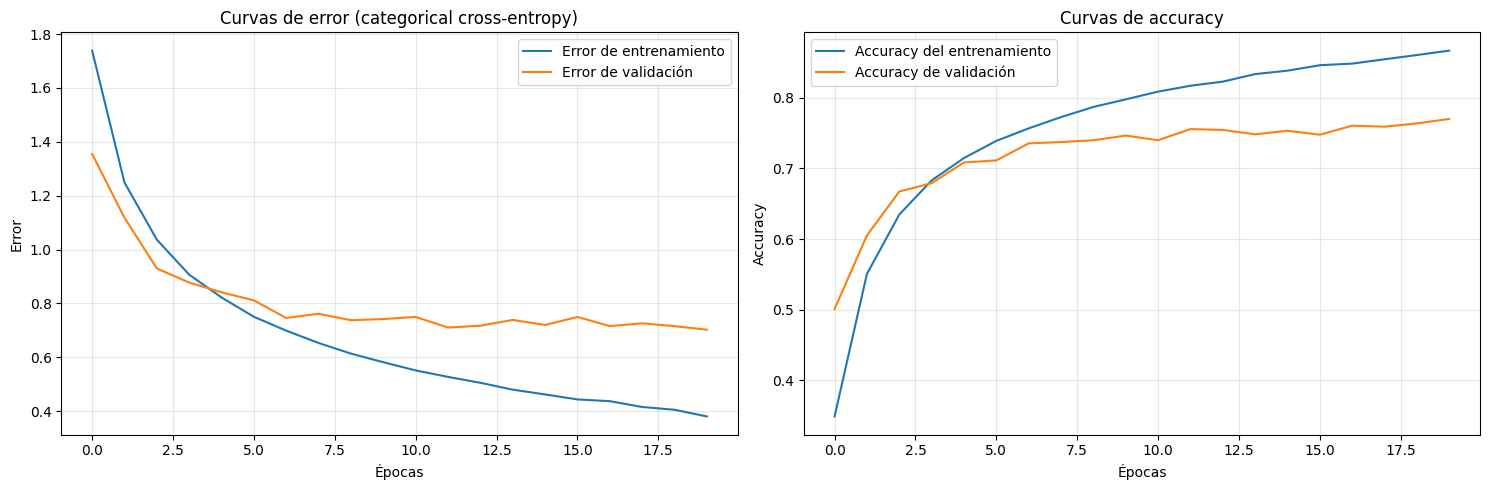

In [18]:
plot_history_graphics(history_drop_12)

In [30]:
model_drop_12.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 5ms/step - accuracy: 0.7697 - loss: 0.7100


[0.7099539041519165, 0.7696999907493591]

En este caso, nuevamente con p = 0.2 pero 2 capas de dropout (una despues de la ultima capa de convolución y otra luego de la primer capa densa), podemos observar que la curva de error de entrenamiento baja tal cual lo vimos anteriormente. Ademas, la curva de error de validación parece tener un comportamiento similar al anterior.
La red sigue overfitteando, por lo que, aumentar la cantidad de capas no ayuda a mejorar el modelo. Este comportamiento similar al usar p = 0.2 y variar la cantidad de capas, nos lleva a pensar que 0.2 NO es un buen valor de p para este problema.

(Probé varias veces y siempre overfittea)

En cuanto a las curvas de accuracy, no hay mucha diferencia con el modelo anterior (con p = 0.2 pero solo una capa de dropout)

Entrenamos el modelo model_drop_21 con p = 0.5 y una capa droput


In [19]:
model_drop_21 = create_model_droput(0.5, False)
model_drop_21.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model_drop_21.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_21 = model_drop_21.fit(
    x_train_split, y_train_split, epochs=20,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4033 - loss: 1.6043 - val_accuracy: 0.5528 - val_loss: 1.2525
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5978 - loss: 1.1200 - val_accuracy: 0.6430 - val_loss: 1.0402
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6696 - loss: 0.9313 - val_accuracy: 0.6872 - val_loss: 0.9376
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7100 - loss: 0.8240 - val_accuracy: 0.7252 - val_loss: 0.8439
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7395 - loss: 0.7425 - val_accuracy: 0.7358 - val_loss: 0.7880
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7630 - loss: 0.6784 - val_accuracy: 0.7500 - val_loss: 0.7578
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7768 - loss: 0.6345 - val_accuracy: 0.7514 - val_loss: 0.7381
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7932 - loss: 0.5895 

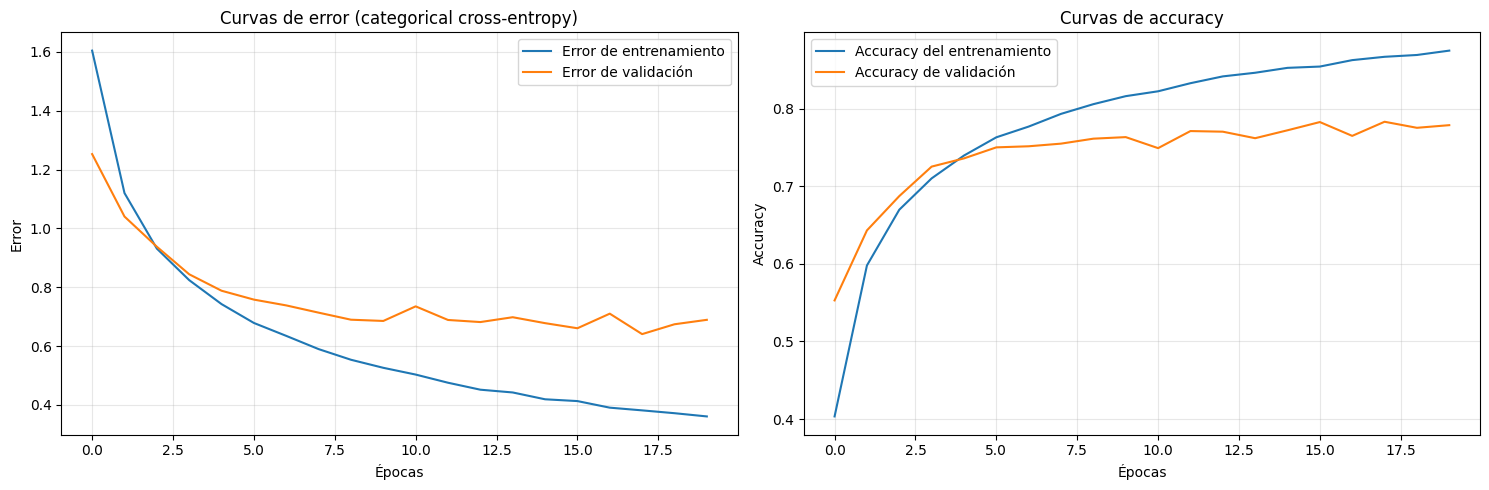

In [21]:
plot_history_graphics(history_drop_21)

In [29]:
model_drop_21.evaluate(x_test, y_test, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.7802 - loss: 0.6643


[0.6642581820487976, 0.7802000045776367]

Para este modelo, utilizando p = 0.5 y una capa de dropout (luego de la ultima capa convolucional), los resultados obtenidos son similares a los obtenidos en el modelo anterior (con p = 0.2 y dos capas de dropout).

Pareciera ala diferencia que se logro entre las curvas de error de validación usando p = 0.2 con una capa de dropout y usando 2 capas, el valor p = 0.5 lo logra con solo una capa de dropout. Esto nos lleva a pensar que 0.5 apunta a ser un valor mas apropiado para este problema.

Entrenamos el modelo model_drop_21 con p = 0.5 y dos capas droput

In [22]:
model_drop_22 = create_model_droput(0.5, True)
model_drop_22.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_drop_22.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_drop_22 = model_drop_22.fit(
    x_train_split, y_train_split, epochs=20,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.2742 - loss: 1.9245 - val_accuracy: 0.4214 - val_loss: 1.5818
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4395 - loss: 1.5207 - val_accuracy: 0.5222 - val_loss: 1.3697
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5144 - loss: 1.3311 - val_accuracy: 0.5796 - val_loss: 1.2471
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5703 - loss: 1.1942 - val_accuracy: 0.6046 - val_loss: 1.1651
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6121 - loss: 1.0923 - val_accuracy: 0.6474 - val_loss: 1.0935
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6395 - loss: 1.0190 - val_accuracy: 0.6370 - val_loss: 1.1302
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6609 - loss: 0.9702 - val_accuracy: 0.6214 - val_loss: 1.1008
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6766 - loss: 0.9283 

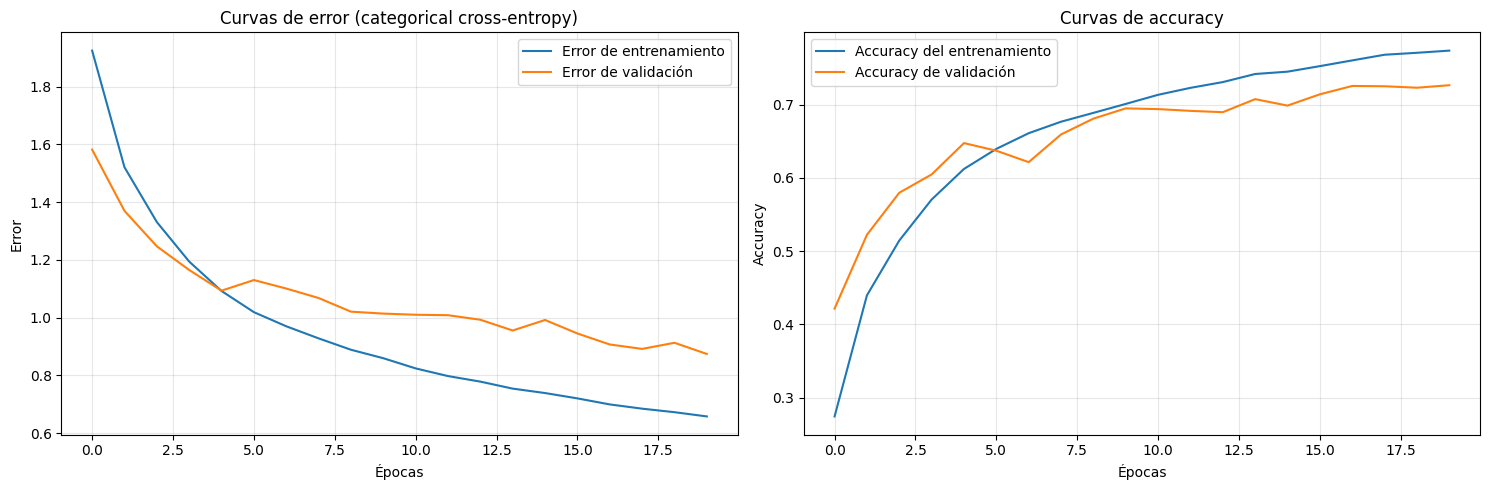

In [24]:
plot_history_graphics(history_drop_22)

In [28]:
model_drop_22.evaluate(x_test, y_test, verbose=2)

313/313 - 2s - 5ms/step - accuracy: 0.7301 - loss: 0.8805


[0.8805444240570068, 0.7300999760627747]

Finalmente, usando p = 0.5 y dos capas de dropout (una despues de la ultima capa de convolución y otra luego de la primer capa densa), vemos que, la curva de error de entrenamiento está un poco por encima de los casos anteriores (0.6 aproximadamente), la curva de error de validación parece finalmente dejar de subir para estancarse en 0.8. Este caso es el que menos overfitting sufre de los 4.

##Concusiones generales (Ejercicio 2)
Analizando los graficos, vemos que, para cada valor de p, usar dos capas de dropout mejora el rendimiento de la red respecto de la que usa solo una capa.

Por otro lado, para este problema en particular, valores bajos de p, es decir, probabilidades mas altas de ignorar algunas neuronas, produce peores resultados que valores mas altos de p.

En esencia, el dropout funciona como una técnica de regularización para evitar el sobreajuste, lograr esto depende del valor de p elegido y en que posición se ubican las capas de dropout, y a su vez, esto de depende meramente del problema. En este caso, la mejor ubicación para la capa de dropout parece ser entre capas densas, ya que en estas capas se corre el riesgo de memorizar el conjunto de entrenamiento y asi generar overfit.

A raiz de lo que obtuvimos, ejegimos p = 0.5 y dos capas de dropout como los valores optimos para el ejercicio.

## Ejercicio 3. Data Augmentation

In [77]:
img_height = 32
img_width = 32

data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1)
])

model_aug = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            data_augmentation,
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(0.5, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])

model_aug.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_33 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
model_aug.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_aug = model_aug.fit(
    x_train_split, y_train_split, epochs=40,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.3477 - loss: 1.7652 - val_accuracy: 0.4628 - val_loss: 1.5059
Epoch 2/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4784 - loss: 1.4246 - val_accuracy: 0.5430 - val_loss: 1.3057
Epoch 3/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5392 - loss: 1.2763 - val_accuracy: 0.5860 - val_loss: 1.2114
Epoch 4/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.5760 - loss: 1.1893 - val_accuracy: 0.6298 - val_loss: 1.0919
Epoch 5/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6009 - loss: 1.1258 - val_accuracy: 0.6326 - val_loss: 1.0589
Epoch 6/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6173 - loss: 1.0776 - val_accuracy: 0.6508 - val_loss: 1.0058
Epoch 7/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.6363 - loss: 1.0296 - val_accuracy: 0.6738 - val_loss: 0.9704
Epoch 8/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6445 -

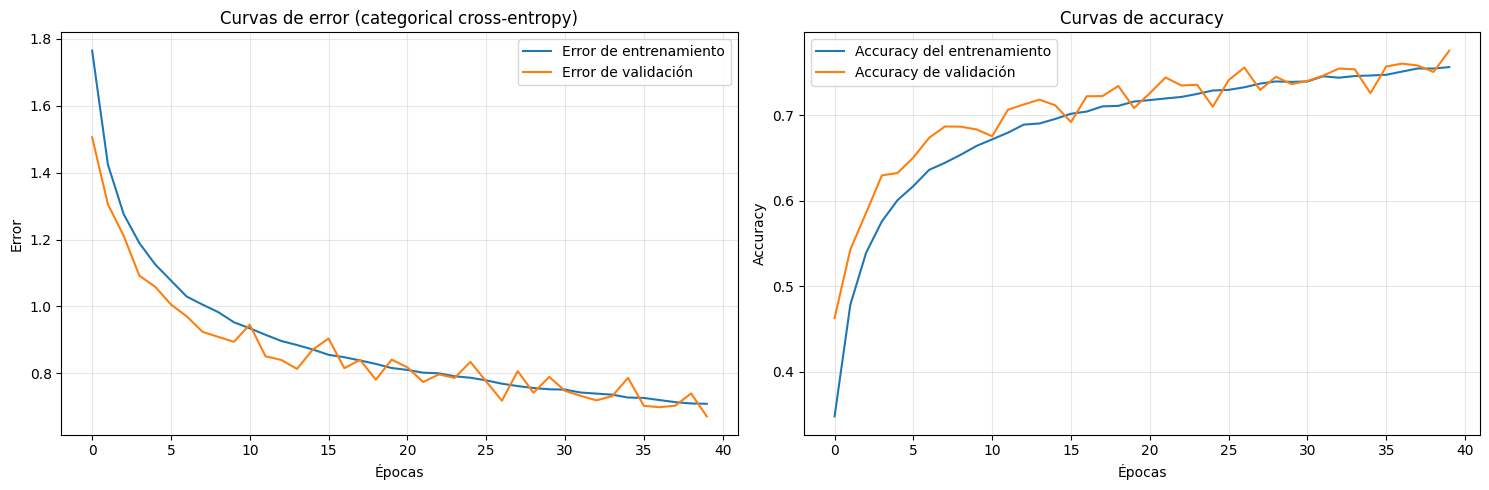

In [79]:
plot_history_graphics(history_aug)

In [80]:
model_aug.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7689 - loss: 0.6941


[0.6940906047821045, 0.7688999772071838]

Corremos una con 80 epocas para ver que, efectivamente, el data augmentation mejora la red, solo que lo hace a un ritmo mas lento.

In [81]:
model_aug_80ep = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            data_augmentation,
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(0.5, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])

model_aug_80ep.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_33 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model_aug_80ep.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_aug_80ep = model_aug_80ep.fit(
    x_train_split, y_train_split, epochs=80,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3280 - loss: 1.8202 - val_accuracy: 0.4464 - val_loss: 1.5511
Epoch 2/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4704 - loss: 1.4481 - val_accuracy: 0.5014 - val_loss: 1.4130
Epoch 3/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5314 - loss: 1.3023 - val_accuracy: 0.5716 - val_loss: 1.2389
Epoch 4/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.5671 - loss: 1.2064 - val_accuracy: 0.5860 - val_loss: 1.1619
Epoch 5/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5932 - loss: 1.1407 - val_accuracy: 0.6514 - val_loss: 1.0193
Epoch 6/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6121 - loss: 1.0904 - val_accuracy: 0.6532 - val_loss: 1.0489
Epoch 7/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6247 - loss: 1.0564 - val_accuracy: 0.6426 - val_loss: 1.0372
Epoch 8/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6370 -

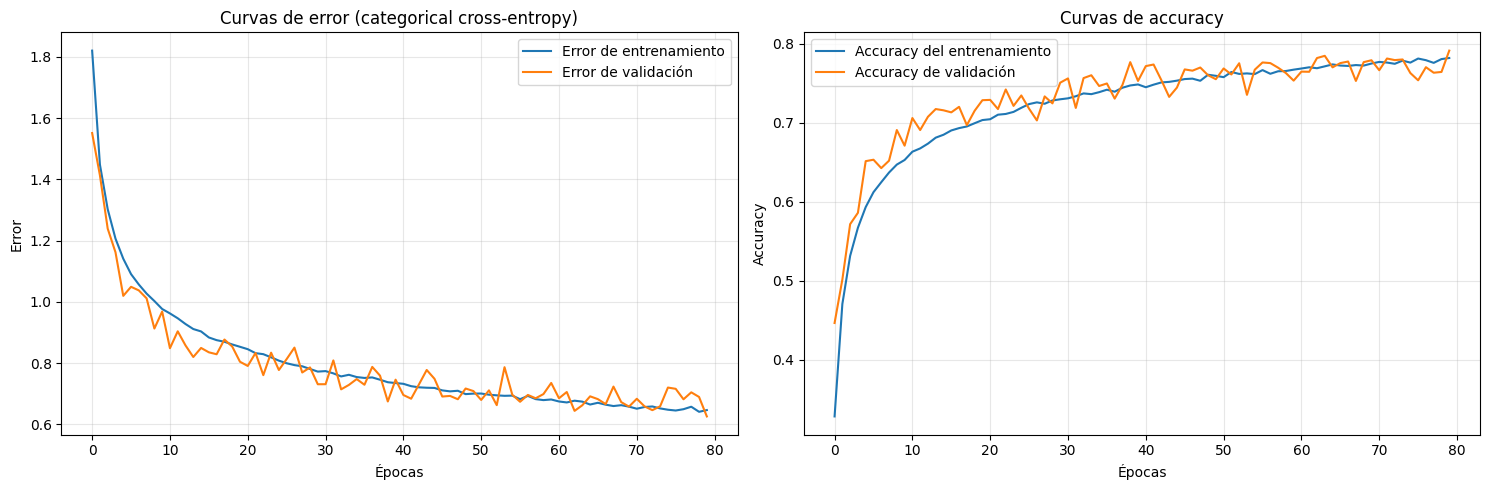

In [83]:
plot_history_graphics(history_aug_80ep)

In [84]:
model_aug_80ep.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7887 - loss: 0.6293


[0.6293155550956726, 0.7886999845504761]

## Ejercicio 4. Transfer Learning

TODO: Hay que hacer con dropout? Probablemente hay que agregar las optimizaciones del 1)!

In [ ]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

In [ ]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [ ]:
# Elegimos arbitrariamente las últimas dos clases para simplificar su eliminación
cond = y_train < 8
x_train8 = x_train[cond]
y_train8 = y_train[cond]

In [ ]:
y_train8

array([0, 6, 0, ..., 1, 1, 5], shape=(40000,))

In [ ]:
cond = y_test < 8
x_test8 = x_test[cond]
y_test8 = y_test[cond]

In [ ]:
y_test8

array([3, 0, 6, ..., 5, 1, 7], shape=(8000,))

In [ ]:
model_cifar8 = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    layers.Dense(8, activation='softmax', name='output') # 8 capas de salida
])

In [ ]:
model_cifar8.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,248 (1.60 MB)

 Trainable params: 418,248 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

TODO: Loss elegido ok? Métricas?

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train8_split, x_val8_split, y_train8_split, y_val8_split = \
    train_test_split(x_train8, y_train8, test_size=0.1, stratify=y_train8)

TODO: Cantidad épocas? Usar Model Checkpoint para agarrar con la mejor validación?

In [ ]:
history_cifar8 = model_cifar8.fit(
    x_train8_split, y_train8_split, epochs=10,
    validation_data=(x_val8_split, y_val8_split)
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4166 - loss: 1.5287 - val_accuracy: 0.5393 - val_loss: 1.2303
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5798 - loss: 1.1395 - val_accuracy: 0.6133 - val_loss: 1.0741
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6432 - loss: 0.9814 - val_accuracy: 0.6560 - val_loss: 0.9502
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6928 - loss: 0.8581 - val_accuracy: 0.6720 - val_loss: 0.9124
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7276 - loss: 0.7627 - val_accuracy: 0.6917 - val_loss: 0.8651
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7566 - loss: 0.6846 - val_accuracy: 0.7005 - val_loss: 0.8690
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7852 - loss: 0.6083 - val_accuracy: 0.7153 - val_loss: 0.8567
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8075 - loss: 0.5443 - 

In [ ]:
cond = y_train >= 8
x_train2 = x_train[cond] - 8   # Restamos para tener clases 0,1
y_train2 = y_train[cond] - 8

In [ ]:
y_train2

array([0, 0, 1, ..., 0, 1, 1], shape=(10000,))

In [ ]:
cond = y_test >= 8
x_test2 = x_test[cond] - 8
y_test2 = y_test[cond] - 8

In [ ]:
y_test2

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [ ]:
model_cifar8.pop()
for layer in model_cifar8.layers:
    layer.trainable = False

In [ ]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   N   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 417,216 (1.59 MB)

 Optimizer params: 836,498 (3.19 MB)

In [ ]:
model_cifar2 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2.summary()

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 417,216 (1.59 MB)

In [ ]:
model_cifar2.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2 = model_cifar2.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5082 - loss: 1.6986 - val_accuracy: 0.5690 - val_loss: 0.6861
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6096 - loss: 0.6635 - val_accuracy: 0.6540 - val_loss: 0.6247
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6508 - loss: 0.6318 - val_accuracy: 0.7050 - val_loss: 0.5935
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6659 - loss: 0.6137 - val_accuracy: 0.6580 - val_loss: 0.5999
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6660 - loss: 0.6142 - val_accuracy: 0.6990 - val_loss: 0.5845
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6727 - loss: 0.6117 - val_accuracy: 0.6440 - val_loss: 0.6325
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6746 - loss: 0.6048 - val_accuracy: 0.6630 - val_loss: 0.5950
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6681 - loss: 0.6095 - val_accuracy: 0

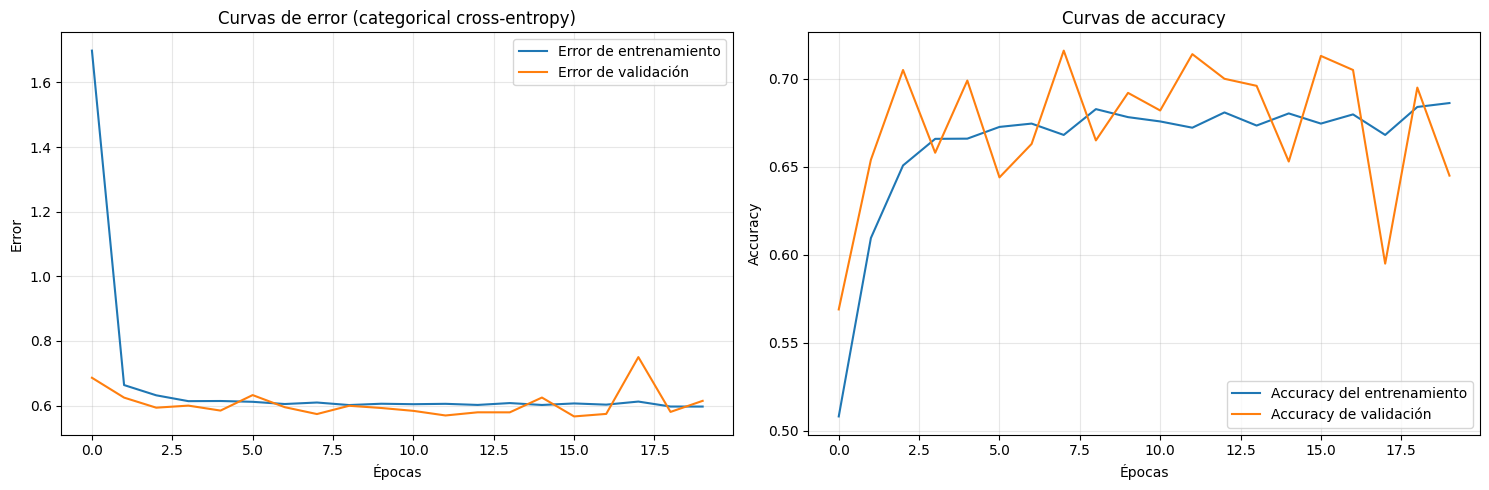

In [ ]:
plot_history_graphics(history_cifar2)

In [ ]:
model_cifar2.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.2290 - loss: 1.8824


[1.882355809211731, 0.2290000021457672]

#### Descongelando la última capa

In [ ]:
model_cifar8.layers[-1].trainable = True

In [ ]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 16,512 (64.50 KB)

 Non-trainable params: 400,704 (1.53 MB)

 Optimizer params: 836,498 (3.19 MB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze1 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze1.summary()

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 16,770 (65.51 KB)

 Non-trainable params: 400,704 (1.53 MB)

In [ ]:
model_cifar2_unfreeze1.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze1 = model_cifar2_unfreeze1.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5548 - loss: 0.9993 - val_accuracy: 0.6020 - val_loss: 0.6641
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6611 - loss: 0.6272 - val_accuracy: 0.7040 - val_loss: 0.5884
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6797 - loss: 0.6072 - val_accuracy: 0.7180 - val_loss: 0.5669
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6821 - loss: 0.6050 - val_accuracy: 0.7150 - val_loss: 0.5671
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6844 - loss: 0.6016 - val_accuracy: 0.7260 - val_loss: 0.5637
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6879 - loss: 0.5971 - val_accuracy: 0.7250 - val_loss: 0.5636
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6842 - loss: 0.6035 - val_accuracy: 0.7200 - val_loss: 0.5678
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6978 - loss: 0.5866 - val_accuracy: 0.

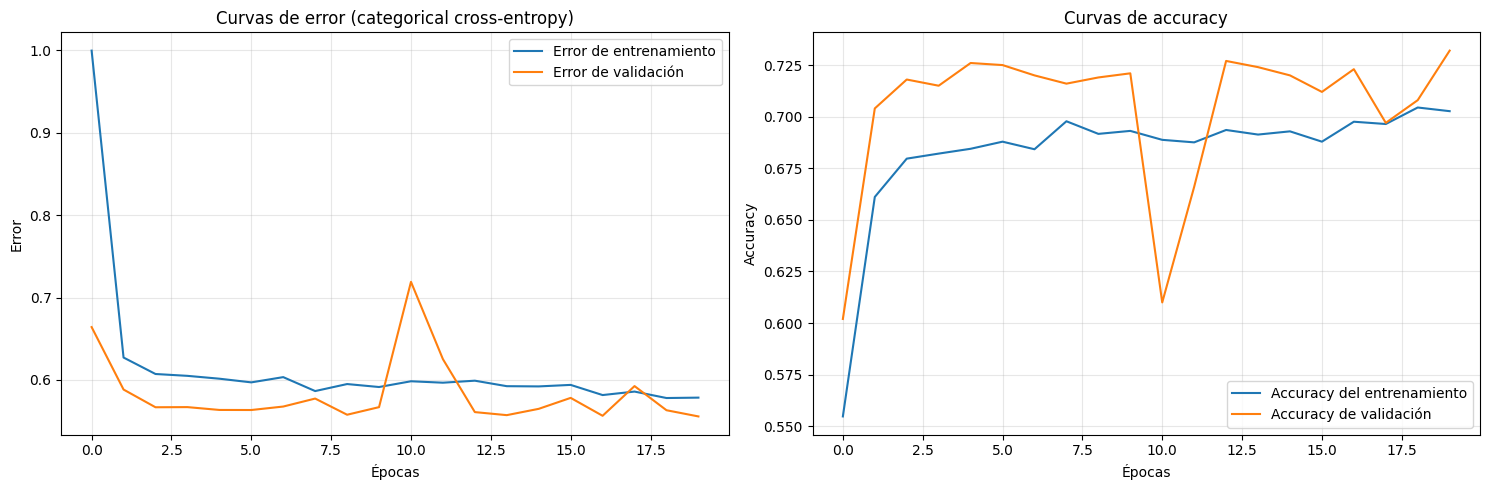

In [ ]:
plot_history_graphics(history_cifar2_unfreeze1)

In [ ]:
model_cifar2_unfreeze1.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.7045 - loss: 0.5717


[0.5717491507530212, 0.7045000195503235]

#### Descongelando las capas densas

(TODO) Al ver que no se obtuvieron mejores resultados, elegimos descongelar todas las capas densas:

In [ ]:
for i in [-1,-2,-3]:
    model_cifar8.layers[i].trainable = True

In [ ]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 287,040 (1.09 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze_dense = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze_dense.summary()

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 287,298 (1.10 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [ ]:
model_cifar2_unfreeze_dense.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze_dense = model_cifar2_unfreeze_dense.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6964 - loss: 0.5818 - val_accuracy: 0.7260 - val_loss: 0.5447
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7700 - loss: 0.4894 - val_accuracy: 0.7300 - val_loss: 0.5444
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.4498 - val_accuracy: 0.7190 - val_loss: 0.5474
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7932 - loss: 0.4436 - val_accuracy: 0.8110 - val_loss: 0.3924
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4275 - val_accuracy: 0.8310 - val_loss: 0.3683
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8170 - loss: 0.3994 - val_accuracy: 0.8310 - val_loss: 0.3657
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8200 - loss: 0.3939 - val_accuracy: 0.8390 - val_loss: 0.3526
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8281 - loss: 0.3830 - val_accuracy: 0.

TODO: Model checkpoint?

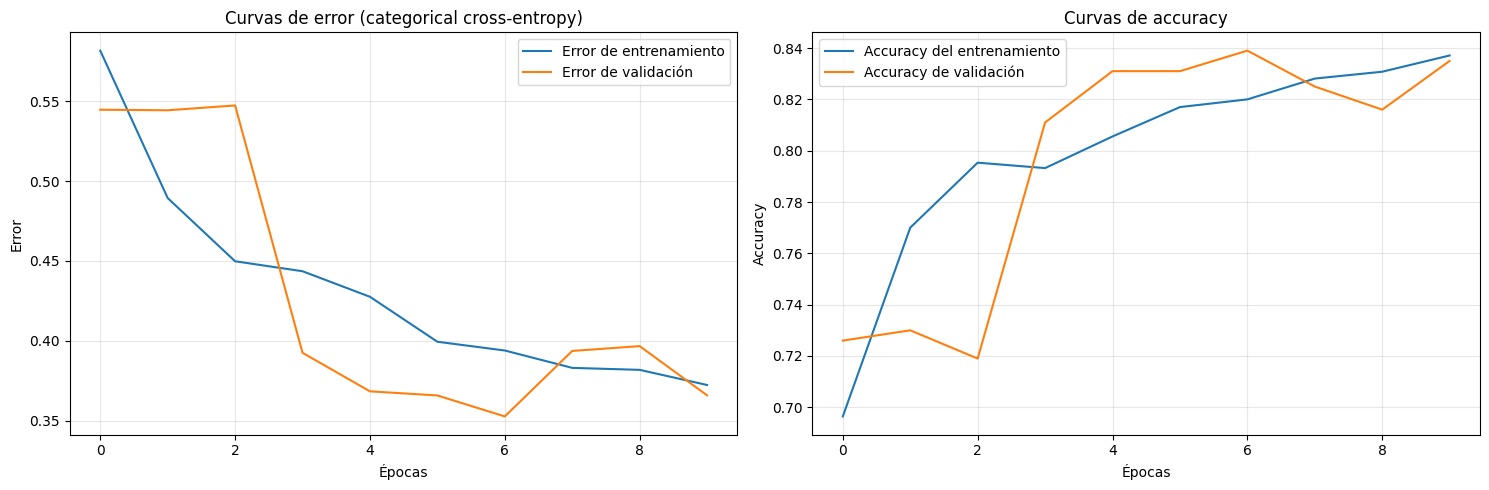

In [ ]:
plot_history_graphics(history_cifar2_unfreeze_dense)

In [ ]:
model_cifar2_unfreeze_dense.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.8170 - loss: 0.4165


[0.41654080152511597, 0.8169999718666077]

#### Descongelando las últimas capas convolucionales

In [ ]:
for i in range(-6,0):
    model_cifar8.layers[i].trainable = True

In [ ]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 360,896 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze_lastconv = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze_lastconv.summary()

Model: "sequential_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 361,154 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [ ]:
model_cifar2_unfreeze_lastconv.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze_lastconv = model_cifar2_unfreeze_lastconv.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7614 - loss: 0.5180 - val_accuracy: 0.8280 - val_loss: 0.4069
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - loss: 0.4337 - val_accuracy: 0.7060 - val_loss: 0.6810
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8077 - loss: 0.4172 - val_accuracy: 0.8430 - val_loss: 0.3706
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8368 - loss: 0.3685 - val_accuracy: 0.8250 - val_loss: 0.4020
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8331 - loss: 0.3679 - val_accuracy: 0.8530 - val_loss: 0.3542
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.3461 - val_accuracy: 0.7440 - val_loss: 0.6184
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8469 - loss: 0.3443 - val_accuracy: 0.8390 - val_loss: 0.4022
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.3288 - val_accuracy: 0.

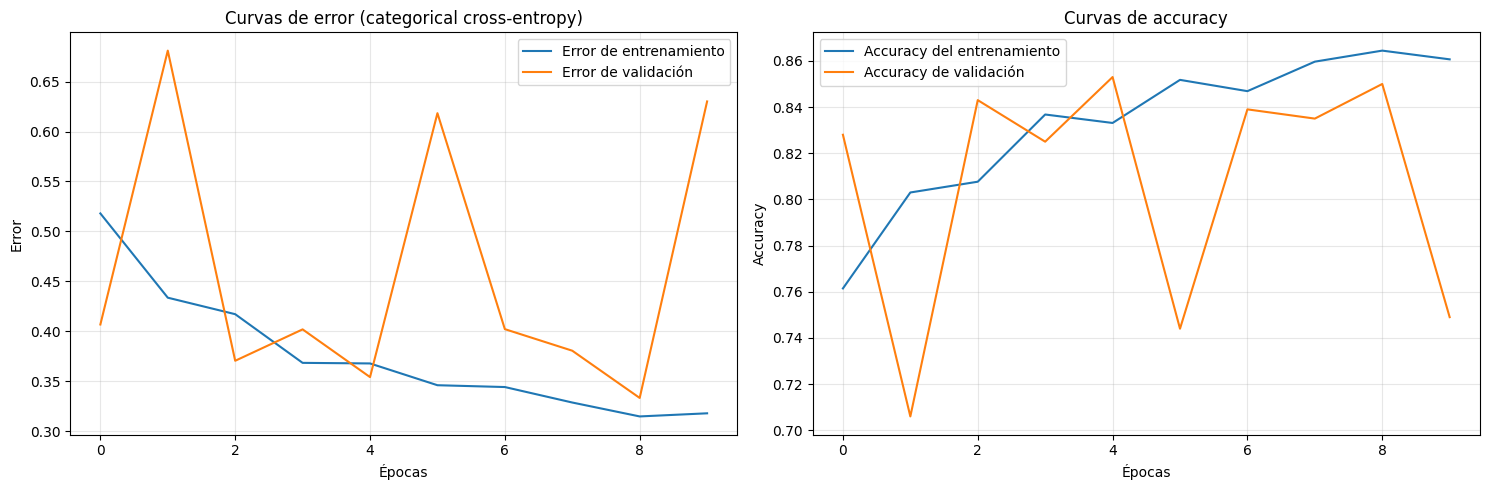

In [ ]:
plot_history_graphics(history_cifar2_unfreeze_lastconv)

In [ ]:
model_cifar2_unfreeze_lastconv.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.7440 - loss: 0.6127


[0.6126516461372375, 0.7440000176429749]

TODO: Model checkpoint? Probar con cantidades de capas intermedias? Probar con más? Notar que el óptimo acá fue aún mejor respecto al anterior, entonces capaz usando checkpoint va mejor el accuracy respecto a test.
    Métricas?